# A Systematically Evaluated Interpretable Enhancement to Fuzzy Q-Learning (FQL-GTA)

**Author:** Karthikeyan K
**Institution:** REVA University -- MS in Artificial Intelligence & Machine Learning
**Advisor:** Dr. J. B. Simha
**Status:** Manuscript prepared for journal submission. Not yet submitted to any venue. DOI: Not yet assigned.

This notebook is an executable companion to `Manuscript/FQL-GTA_Final_Manuscript.docx`. It
demonstrates the FQL-GTA agent mechanism directly (a short live training run below) and then
loads the actual reported results from `Results/`, so every number shown here is either computed
live in this notebook or read from the same files the manuscript reads from -- never
hand-typed, and never out of sync with the paper.

**Research questions:**
1. Does combining Gaussian membership functions, Q(lambda) eligibility traces, and adaptive
   epsilon produce a statistically defensible improvement over classical Fuzzy Q-Learning?
2. Do CartPole-tuned hyperparameters transfer zero-shot to other control environments?


## 1. Setup and frozen configuration

All hyperparameters below are read live from `configs/default_config.json` -- the single
frozen configuration every script in this repository uses. This is a deliberate fix from an
earlier draft of this notebook, which described a stale 81-rule / lambda=0.90 configuration that
no longer matches the code, manuscript, or results; that inconsistency has been resolved by
having this cell read the frozen config directly rather than re-describing it by hand.

In [1]:
import sys, json
from pathlib import Path

NB_DIR = Path.cwd()
ROOT = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR
CODE_DIR = ROOT / "Code"
RESULTS_DIR = ROOT / "Results"
FIGURES_DIR = ROOT / "Figures"
sys.path.insert(0, str(CODE_DIR))

with open(ROOT / "configs" / "default_config.json") as f:
    config = json.load(f)

print("Baseline FQL:", json.dumps(config["baseline_fql"], indent=2))
print("\nProposed FQL-GTA:", json.dumps(config["fql_gta_proposed"], indent=2))
print("\nPrimary comparison protocol:", json.dumps(config["primary_comparison"], indent=2))

Baseline FQL: {
  "alpha": 0.3,
  "gamma": 0.99,
  "epsilon": 0.1,
  "epsilon_schedule": "fixed (no decay)",
  "membership_functions": "triangular",
  "n_rules_cartpole": 324,
  "sets_per_dim_cartpole": [
    3,
    3,
    6,
    6
  ]
}

Proposed FQL-GTA: {
  "alpha": 0.2,
  "gamma": 0.99,
  "epsilon_start": 0.5,
  "epsilon_min": 0.005,
  "epsilon_decay": 0.99,
  "lambda_eligibility_trace": 0.5,
  "membership_functions": "Gaussian",
  "sigma_mult": 0.35,
  "n_rules_cartpole": 324,
  "sets_per_dim_cartpole": [
    3,
    3,
    6,
    6
  ]
}

Primary comparison protocol: {
  "seeds": "0-29 (30 independent seeds)",
  "n_seeds": 30,
  "episodes_per_seed": 500,
  "solve_threshold": 475.0,
  "solve_window_episodes": 50,
  "solved_definition": "trailing-50-episode mean at the FINAL episode >= solve_threshold (not merely ever crossing it)"
}


## 2. Live demonstration run

A short training run (3 seeds, 150 episodes -- far smaller than the 30-seed, 500-episode budget
used for the reported results) to demonstrate the two agents actually training end to end in this
notebook. **The numbers in this section are illustrative only**; the authoritative, reported
results (30 seeds, 500 episodes each) are loaded from `Results/` in Section 3.

seed 0: baseline last-20 mean=17.6, improved last-20 mean=475.7


seed 1: baseline last-20 mean=16.8, improved last-20 mean=216.2


seed 2: baseline last-20 mean=112.5, improved last-20 mean=26.1


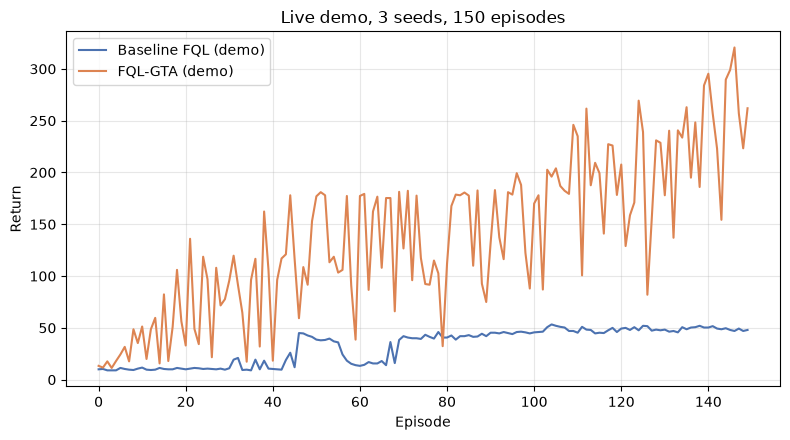

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from fql_baseline import FuzzyQLearningBaseline, train as train_baseline
from fql_improved import FuzzyQLearningImproved, train as train_improved

DEMO_SEEDS = [0, 1, 2]
DEMO_EPISODES = 150

demo_curves = {"baseline": [], "improved": []}
for seed in DEMO_SEEDS:
    h_base = train_baseline(FuzzyQLearningBaseline(seed=seed), episodes=DEMO_EPISODES, seed=seed)
    h_imp = train_improved(FuzzyQLearningImproved(seed=seed), episodes=DEMO_EPISODES, seed=seed)
    demo_curves["baseline"].append(h_base)
    demo_curves["improved"].append(h_imp)
    print(f"seed {seed}: baseline last-20 mean={h_base[-20:].mean():.1f}, "
          f"improved last-20 mean={h_imp[-20:].mean():.1f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.mean(demo_curves["baseline"], axis=0), label="Baseline FQL (demo)", color="#4C72B0")
ax.plot(np.mean(demo_curves["improved"], axis=0), label="FQL-GTA (demo)", color="#DD8452")
ax.set_xlabel("Episode"); ax.set_ylabel("Return"); ax.set_title(f"Live demo, {len(DEMO_SEEDS)} seeds, {DEMO_EPISODES} episodes")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Reported results (30 seeds, 500 episodes each)

These are the actual numbers reported in the manuscript, loaded directly from
`Results/metrics.json` -- the same file the manuscript generator script reads.

In [3]:
with open(RESULTS_DIR / "metrics.json") as f:
    metrics = json.load(f)

import pandas as pd
summary_rows = []
for agent in ["Baseline FQL", "Improved FQL-GTA"]:
    m = metrics[agent]
    summary_rows.append({
        "Agent": agent,
        "Final return (mean +/- SD)": f"{m['final_return_mean']:.1f} +/- {m['final_return_std']:.1f}",
        "Median": f"{m['final_return_median']:.1f}",
        "95% CI": f"[{m['final_return_95ci'][0]:.1f}, {m['final_return_95ci'][1]:.1f}]",
        "Solve rate": f"{m['solved_rate']:.0%}",
        "n seeds": m["n_seeds_total"],
    })
pd.DataFrame(summary_rows)

,Agent,Final return (mean +/- SD),Median,95% CI,Solve rate,n seeds
0,Baseline FQL,265.7 +/- 41.2,278.7,"[250.3, 281.1]",0%,30
1,Improved FQL-GTA,423.1 +/- 78.7,450.1,"[393.7, 452.5]",40%,30


In [4]:
with open(RESULTS_DIR / "statistical_tests.json") as f:
    stats_j = json.load(f)
pc = stats_j["primary_comparison"]
print(f"Paired Wilcoxon signed-rank test: p = {pc['wilcoxon_p_value']:.3e}")
print(f"Cohen's d (trailing-50 return): {pc['cohens_d_trailing50_return']:.2f}")
print(f"Shapiro-Wilk (baseline): p = {pc['shapiro_wilk_baseline']['p_value']:.3e} (normality rejected)")
print(f"Shapiro-Wilk (FQL-GTA): p = {pc['shapiro_wilk_gta']['p_value']:.3e} (normality rejected)")

Paired Wilcoxon signed-rank test: p = 3.539e-08
Cohen's d (trailing-50 return): 2.51
Shapiro-Wilk (baseline): p = 6.261e-07 (normality rejected)
Shapiro-Wilk (FQL-GTA): p = 4.965e-04 (normality rejected)


### Full 2^3 factorial ablation (8 conditions x 3 seeds)

In [5]:
ablation = pd.read_csv(RESULTS_DIR / "ablation_summary.csv")
ablation

,label,avg_reward,std_dev,trailing50_mean
0,Off / Off / Off (baseline FQL),45.285000,45.021448,72.706667
1,Off / Off / On,70.561667,35.389506,214.926667
2,Off / On / Off,21.972500,10.481916,70.960000
3,Off / On / On,146.452500,19.758981,280.686667
4,On / Off / Off,94.275000,44.581927,230.306667
5,On / Off / On,100.026667,13.679485,227.260000
6,On / On / Off,163.735000,25.073943,421.493333
7,On / On / On (full FQL-GTA),305.530833,105.121405,476.513333


## 4. Interpretability: one real traced decision

Read directly from `Results/learned_rules_worked_examples.json` -- nothing here is illustrative.

In [6]:
with open(RESULTS_DIR / "learned_rules_worked_examples.json") as f:
    rules = json.load(f)

ex = rules["examples"][0]
top = ex["top_firing_rules"][0]
print(f"State: {[round(x,3) for x in ex['raw_state']]}")
print(f"{ex['n_rules_firing_above_0.01']} of {ex['n_rules_total']} rules fire above 0.01")
print(f"Dominant rule {top['rule_index']}: firing={top['firing_strength']:.1%}, "
      f"Q(left)={top['q_push_left']:.2f}, Q(right)={top['q_push_right']:.2f}")
print(f"Blended: Q(left)={ex['blended_q_values']['push_left']:.2f}, "
      f"Q(right)={ex['blended_q_values']['push_right']:.2f} -> {ex['selected_action']}")

State: [0.028, -0.033, 0.021, 0.025]
4 of 324 rules fire above 0.01
Dominant rule 165: firing=44.5%, Q(left)=102.65, Q(right)=100.28
Blended: Q(left)=98.22, Q(right)=98.01 -> push cart left


## 5. Where to find everything else

- Full 30-seed / full-factorial / sensitivity / cross-environment-transfer / deep-RL-baseline
  pipelines: see the individual `Code/run_*.py` scripts (also listed in `README/README.md`).
- All figures: `Figures/`.
- Full manuscript: `Manuscript/FQL-GTA_Final_Manuscript.docx` (also `PDF/`).
- This notebook intentionally does not re-run the full 30-seed study (that takes ~25-40 minutes);
  Section 2 above is a fast, illustrative demonstration only.